In [11]:
# applying some functions on the colums to make it normally distributed is called fuction transformation
# but why do we need to make the data normally distributed?
# because many machine learning algorithms assume that the data is normally distributed, and if it is not, it can lead to poor performance of the model.
# for example, linear regression assumes that the residuals (the difference between the predicted and actual values) are normally distributed, and if they are not, it can lead to biased estimates of the coefficients and poor predictions.


In [12]:
# sklearn has 3 tyoes of function transformers:
# 1. PowerTransformer: This transformer applies a power transformation to the data, which can   make it more normally distributed. It has two methods: 'yeo-johnson' and 'box-cox'. The 'yeo-johnson' method can handle both positive and negative values, while the 'box-cox' method can only handle positive values.
# 2. QuantileTransformer: This transformer applies a quantile transformation to the data, which can also make it more normally distributed. It has two methods: 'uniform' and 'normal'. The 'uniform' method transforms the data to a uniform distribution, while the 'normal' method transforms the data to a normal distribution.
# 3. FunctionTransformer: This transformer applies a user-defined function to the data, which can be used to make it more normally distributed. For example, you can use the logarithm function to transform skewed data to a more normal distribution. 

In [13]:
# how to find if data is normally distributed or not?
# we can use the following methods to find if data is normally distributed or not:
#sns.distplot(df['column_name'])
# or pd.skew(df['column_name'])
# or QQ plot


In [14]:
# LOG TRANSFORM KAHA LAGANA CHAHIYE??
# Right skewed data par log transform lagana chahiye, jisse data normal distribution ke kareeb aa jaye. Skewed data wo hota hai jisme ek tail zyada lambi hoti hai, aur log transform se wo tail chhoti ho jati hai, aur data normal distribution ke kareeb aa jata hai.


In [15]:
# OTHER TRANSFORMS INCLUDE:
# 1. Square root transform: This transform can be used to reduce the skewness of the data. It is particularly useful for count data, where the variance increases with the mean.

#SQUARE TRANSFORM: This transform can be used to increase the skewness of the data. It is particularly useful for data that is already normally distributed, but has a small amount of skewness.(for left skewed data)

# Reciprocal transform: This transform can be used to reduce the skewness of the data. It is particularly useful for data that has a long tail on the right side.

In [16]:
import numpy as np
import pandas as pd

# for QQ plot
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [17]:
df = pd.read_csv('titanic.csv', usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [18]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [19]:
df['Age'].fillna(df['Age'].mean(), inplace=True)


C:\Users\gurpr\AppData\Local\Temp\ipykernel_24704\1226013979.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [20]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [21]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\gurpr\AppData\Local\Temp\ipykernel_24704\3694164400.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


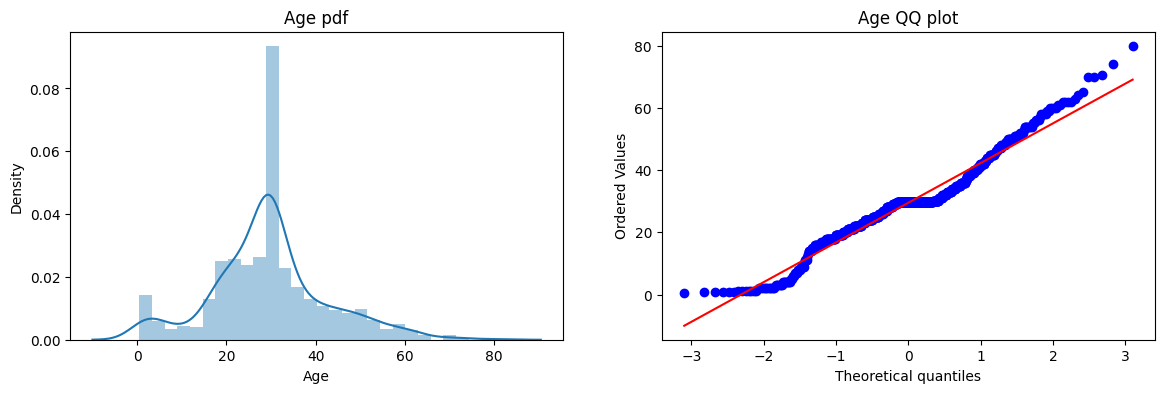

In [24]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ plot')    

plt.show()

C:\Users\gurpr\AppData\Local\Temp\ipykernel_24704\1468273503.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


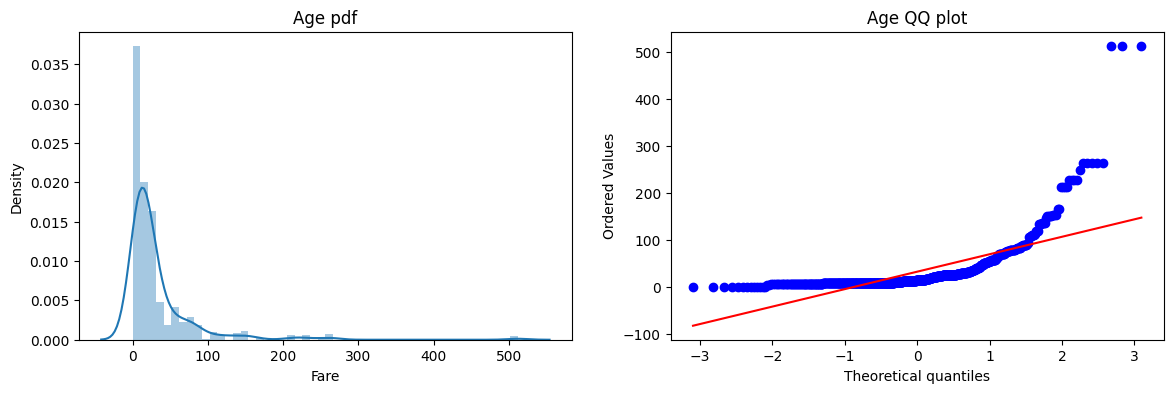

In [ ]:
# FARE COLUMN
plt.figure(figsize=(14,4))
plt.subplot(121) #121 means 1 row, 2 columns, and this is the first plot. here the row is 1 because we want to plot only one row, and the column is 2 because we want to plot two plots side by side.
sns.distplot(X_train['Fare'])
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Age QQ plot')    

plt.show()
# hence we will go for log transform for fare column

FITTIG IN BOTH DECISION TREE CLASSIFIER AND LOGISTIC REGRESSION WITHOUT USING TRANSFORM

In [26]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

# without log transform
clf1.fit(X_train, y_train)
y_pred1 = clf1.predict(X_test)

clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred1))
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.6480446927374302
Decision Tree Accuracy: 0.659217877094972


NOW APPLYING LOG TRANSFORMATION ON FARE

In [ ]:
trf = ColumnTransformer(transformers=[('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough') # log1p is used to handle the zero values in the fare column, because log(0) is undefined, but log1p(0) is 0. it just adds 1 to the value before applying the log transform, so that we can handle the zero values in the fare column.
X_train_trf = trf.fit_transform(X_train)    
X_test_trf = trf.transform(X_test)

# with log transform
clf1.fit(X_train_trf, y_train)
y_pred1_trf = clf1.predict(X_test_trf)

print('Logistic Regression Accuracy with log transform:', accuracy_score(y_test, y_pred1_trf))

clf2.fit(X_train_trf, y_train)
y_pred2_trf = clf2.predict(X_test_trf)
print('Decision Tree Accuracy with log transform:', accuracy_score(y_test, y_pred2_trf))


Logistic Regression Accuracy with log transform: 0.6703910614525139
Decision Tree Accuracy with log transform: 0.6927374301675978


USING CROSS VALIDATION TO CHECK IF THE ACCURACY IS LITERALLY INCREASED

In [28]:
print("LR", np.mean(cross_val_score(clf1, X_train_trf, y_train, cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_train_trf, y_train, cv=10)))

LR 0.6572378716744913
DT 0.620735524256651


OBSERVATION - ACCURACY OF LR INCREASED BUT DT WAS NOT AFFECTED(AS IT IS A NON LINEAR MODEL)